# Emerging Technologies: Quantum Algorithms

A comparative study of classical and quantum approaches to the Deutsch-Jozsa problem.

**Module:** Emerging Technologies  
**Academic Year:** 2025/2026  
**Author:** Eric Murray

## Introduction

### Imports & Housekeeping

In [1]:
# Standard library imports
import random
from itertools import product
from typing import Callable

# Numerical Operations & Visualisations
import matplotlib.pyplot as plt
import numpy as np

# Quantum computing
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit.quantum_info import Statevector

## Problem 1: Generating Random Boolean Functions

### Understanding the Problem

In [classical information theory](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information), we work with systems that can be in one of several classical states. A [Boolean function](https://en.wikipedia.org/wiki/Boolean_function) is a mathematical function that maps Boolean inputs (True/False, or equivalently 0/1) to a Boolean output.

IBM's quantum learning materials introduce this concept with single-bit functions, showing that for one input bit there are four possible Boolean functions, two of which are **constant** (always return the same value) and two of which are **balanced** (return each output value equally). Our task extends this to **four input bits**.

### The Mystery Function Problem

Imagine someone gives you a black box - a function you can't see inside. You can only interact with it by giving it 4 True/False values and seeing what it returns (True or False).

Your task: determine if this mystery function is **constant** (always returns the same answer) or **balanced** (returns True for exactly half the inputs, False for the other half).

**The Classical Approach:**

You start testing:
- Input: (False, False, False, False) → True
- Input: (True, False, False, False) → True  
- Input: (False, True, False, False) → True

So far all True... but you still don't know! It could be:
- **Constant:** Always returns True (for all 16 possible inputs)
- **Balanced:** Returns True for 8 inputs, you just haven't hit a False one yet

You keep testing... after 8 tests that all return True, you STILL can't be certain. Only on the 9th test:
- If it returns True → Must be constant (more than 8 True values)
- If it returns False → Must be balanced (exactly 8 True, rest False)

For 4-bit functions: worst case needs 9 queries. For 10-bit functions: 513 queries. This grows exponentially - the number of required queries is 2^(n-1) + 1 for n input bits.

**The Quantum Solution:**

The [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) is a quantum algorithm that demonstrates quantum advantage by solving this same problem with just **one** query, regardless of how many input bits there are. It achieves this using quantum superposition, where qubits can represent all possible input combinations simultaneously.

To test this quantum algorithm in later problems, we need a way to generate random test functions with known properties.

### Function Types

A Boolean function takes Boolean inputs and returns a Boolean output. For functions with 4 inputs, there are 2⁴ = 16 possible input combinations.

**Constant Function:**  
Returns the same value for all inputs. Only two possibilities exist:
- Always returns `False` (or 0 in binary notation)
- Always returns `True` (or 1 in binary notation)

**Balanced Function:**  
Returns `True` for exactly half the inputs (8 out of 16) and `False` for the other half (8 out of 16). As described in IBM's classical information framework, "each of the two output values occurs the same number of times as we range over the possible inputs."

### Implementation Goal

Our `random_constant_balanced()` function randomly generates one of these special functions. Each time we call it, we get a new random function that is guaranteed to be either constant or balanced.

The implementation uses Python's [`random` module](https://docs.python.org/3/library/random.html) for random selection and [`itertools.product`](https://docs.python.org/3/library/itertools.html#itertools.product) to generate all possible input combinations efficiently.

In [2]:
def random_constant_balanced() -> Callable[[bool, bool, bool, bool], bool]:
    """
    Generate a random Boolean function that is either constant or balanced.
    
    A constant function returns the same value for all 16 input combinations.
    A balanced function returns True for exactly 8 inputs and False for 8.
    
    Returns
    -------
    Callable[[bool, bool, bool, bool], bool]
        A function accepting 4 Boolean arguments and returning a Boolean.
        
    Example
    -------
    >>> f = random_constant_balanced()
    >>> result = f(True, False, True, False)
    >>> isinstance(result, bool)
    True
    """
    # Generate all 16 possible input combinations
    all_inputs = list(product([False, True], repeat=4))
    
    # Create lookup dictionary for the function
    lookup = {}
    
    # Randomly decide if the function is constant or balanced
    is_constant = random.choice([True, False])
    
    if is_constant:
        # Constant - all inputs map to the same output
        constant_value = random.choice([False, True])
        for input_combo in all_inputs:
            lookup[input_combo] = constant_value
    else:
        # Balanced - exactly 8 True, 8 False
        shuffled_inputs = all_inputs.copy()
        random.shuffle(shuffled_inputs)
        
        for i in range(8):
            lookup[shuffled_inputs[i]] = True
        for i in range(8, 16):
            lookup[shuffled_inputs[i]] = False
    
    def generated_function(a: bool, b: bool, c: bool, d: bool) -> bool:
        """Generated Boolean function with predetermined constant or balanced behavior."""
        # Validate input types
        if not all(isinstance(x, bool) for x in (a, b, c, d)):
            raise TypeError("All arguments must be Boolean values")
        return lookup[(a, b, c, d)]
    
    return generated_function

### `random_constant_balanced` - Testing

To verify the implementation is correct, we test that generated functions satisfy the constant or balanced properties.

**Testing Approach:**
- Generate a function using `random_constant_balanced()`
- Query it on all 16 possible input combinations
- Count how many return `True`
- Verify the count matches expected values:
  - **0 True** → Constant (always `False`)
  - **8 True** → Balanced
  - **16 True** → Constant (always `True`)

Any other count indicates a bug in the implementation. This exhaustive testing approach mirrors the classical query method we'll compare against the quantum algorithm in later problems.

In [3]:
# Generate a test function
test_function = random_constant_balanced()

# Get all possible input combinations
all_inputs = list(product([False, True], repeat=4))

# Test the function on all inputs and count True outputs
true_count = sum(test_function(*input_combo) for input_combo in all_inputs)

# Classify and display result
print(f"True count: {true_count}/16")

if true_count == 0:
    print("Function type: Constant (always False)")
elif true_count == 8:
    print("Function type: Balanced")
elif true_count == 16:
    print("Function type: Constant (always True)")
else:
    print(f"ERROR: Invalid function - expected 0, 8, or 16 True values, got {true_count}")

True count: 8/16
Function type: Balanced


### Visualisation

To better understand the problem and why quantum computing offers an advantage, we can visualize two key aspects:

**Figure 1: Query Complexity Growth**

This graph compares how many queries (function calls) are needed to determine if a function is constant or balanced as the number of input bits increases.

- **Classical approach:** Requires 2^(n-1) + 1 queries in the worst case. For 4 bits: 9 queries, for 10 bits: 513 queries
- **Quantum approach:** Requires exactly 1 query regardless of the number of bits

The exponential gap between these approaches demonstrates the fundamental advantage quantum computing can provide for certain problems. As the problem size grows, the classical approach becomes impractical while the quantum approach remains constant.

**Figure 2: Distribution Across Multiple Functions**

This histogram shows the distribution of True outputs across 100 randomly generated functions. Each function was tested on all 16 possible inputs and the number of True outputs was recorded.

The visualization demonstrates two key properties of our implementation:

1. **Validity:** Only three values appear (0, 8, and 16), proving all generated functions are either constant or balanced - no invalid functions are created

2. **Randomness:** The distribution should be roughly:
   - **~25% at 0:** Constant functions (always False)
   - **~50% at 8:** Balanced functions
   - **~25% at 16:** Constant functions (always True)

This even distribution confirms our random selection is working correctly, with balanced functions appearing twice as often as each individual constant type (since there are two constant types but only one balanced type in our random choice).

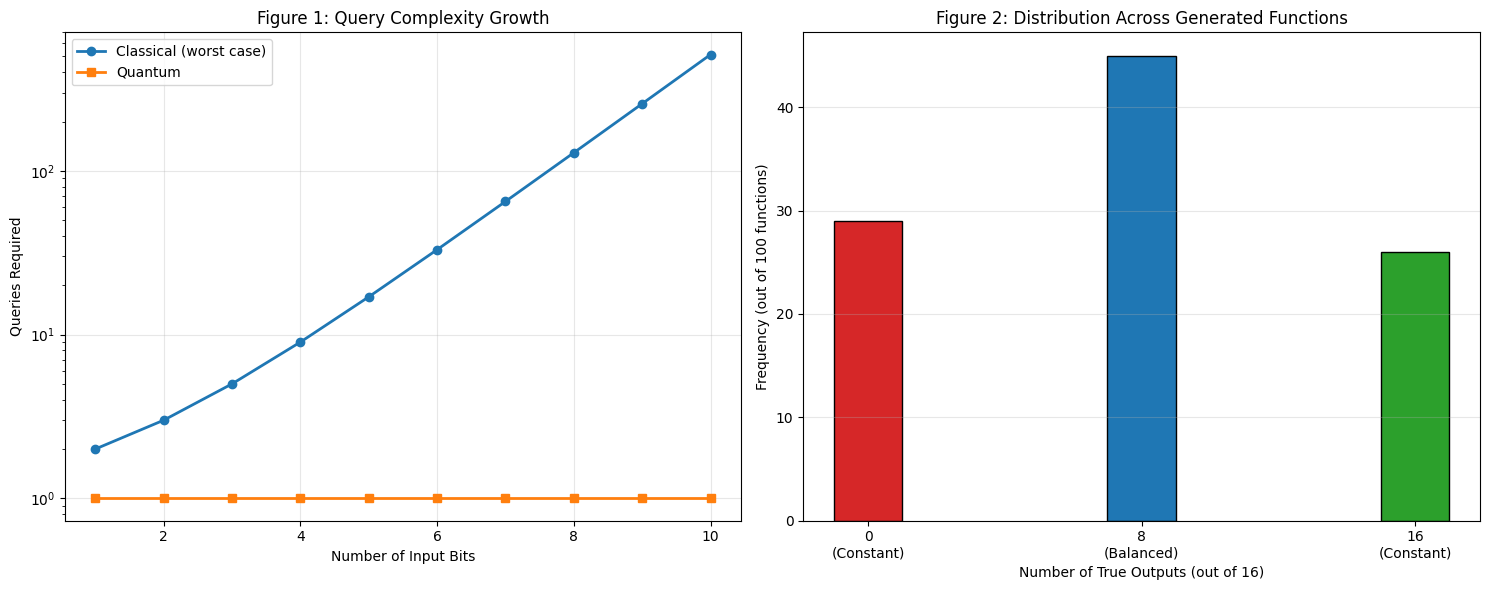


Distribution Summary:
Constant (False): 29% (29 functions)
Balanced:         45% (45 functions)
Constant (True):  26% (26 functions)


In [4]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Query Complexity Growth (Classical vs Quantum)
n_bits = np.arange(1, 11)  # Test from 1 to 10 input bits
classical_queries = 2**(n_bits - 1) + 1  # Exponential worst-case
quantum_queries = np.ones(len(n_bits))   # Always 1 query

ax1.plot(n_bits, classical_queries, 'o-', label='Classical (worst case)', 
         linewidth=2, markersize=6)
ax1.plot(n_bits, quantum_queries, 's-', label='Quantum', 
         linewidth=2, markersize=6)
ax1.set_xlabel('Number of Input Bits')
ax1.set_ylabel('Queries Required')
ax1.set_title('Figure 1: Query Complexity Growth')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Logarithmic scale to show exponential growth clearly

# Figure 2: Distribution validation across 100 generated functions
num_functions = 100
true_counts = []

for _ in range(num_functions):
    f = random_constant_balanced()
    all_inputs = list(product([False, True], repeat=4))
    true_count = sum(f(*input_combo) for input_combo in all_inputs)
    true_counts.append(true_count)

# Count occurrences at each valid value (0, 8, or 16)
counts_at_0 = true_counts.count(0)
counts_at_8 = true_counts.count(8)
counts_at_16 = true_counts.count(16)

# Create bar chart showing distribution
ax2.bar([0, 8, 16], [counts_at_0, counts_at_8, counts_at_16], 
        width=2, color=['#d62728', '#1f77b4', '#2ca02c'], edgecolor='black')
ax2.set_xlabel('Number of True Outputs (out of 16)')
ax2.set_ylabel(f'Frequency (out of {num_functions} functions)')
ax2.set_title('Figure 2: Distribution Across Generated Functions')
ax2.set_xticks([0, 8, 16])
ax2.set_xticklabels(['0\n(Constant)', '8\n(Balanced)', '16\n(Constant)'])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistical summary
print(f"\nDistribution Summary:")
print(f"Constant (False): {counts_at_0}% ({counts_at_0} functions)")
print(f"Balanced:         {counts_at_8}% ({counts_at_8} functions)")
print(f"Constant (True):  {counts_at_16}% ({counts_at_16} functions)")

## Problem 2: Classical Testing for Function Type

### The Classical Algorithm Challenge

In Problem 1, we built a generator for constant and balanced Boolean functions. Now we need a classical algorithm to determine which type a mystery function is - this represents the **classical computational approach** to the problem that the quantum algorithm will later solve more efficiently.

**The Constraint:**

We cannot look inside the function - we can only query it with different inputs and observe the outputs. This "black box" scenario is fundamental to understanding computational complexity. As described in [classical information theory](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/single-systems/classical-information), we must determine global properties of a function through local queries.

**The Classification Problem:**

Given a Boolean function `f` with 4 inputs (guaranteed to be either constant or balanced), determine its type by:
1. Querying `f` with various input combinations
2. Analyzing the output patterns
3. Returning either `"constant"` or `"balanced"`

The efficiency of this classical approach will serve as our baseline for comparison with the quantum algorithm in later problems.

In [5]:
def determine_constant_balanced(f: Callable[[bool, bool, bool, bool], bool]) -> str:
    """
    Classically determine if a 4-input Boolean function is constant or balanced.
    
    Parameters
    ----------
    f : Callable[[bool, bool, bool, bool], bool]
        A Boolean function taking 4 Boolean arguments
        
    Returns
    -------
    str
        Either "constant" or "balanced"
        
    Notes
    -----
    This implementation queries all 16 possible inputs to determine the
    function type. While comprehensive, this is not the most efficient
    approach possible.
    """
    # Generate all possible input combinations
    all_inputs = list(product([False, True], repeat=4))
    
    # Count how many inputs return True
    true_count = sum(f(*input_combo) for input_combo in all_inputs)
    
    # Classify based on count
    if true_count == 0 or true_count == 16:
        return "constant"
    elif true_count == 8:
        return "balanced"
    else:
        raise ValueError(f"Invalid function: {true_count} True outputs (expected 0, 8, or 16)")

### Efficiency Analysis

**Query Complexity:**

Our implementation queries all 16 possible inputs - a comprehensive but inefficient approach. The theoretical worst case actually requires far fewer queries.

**Worst-Case Scenario:**

Imagine querying inputs sequentially and getting unlucky:

1. **Queries 1-8:** All return `True` 
   - Could be: Constant (always True) OR Balanced (haven't hit False yet)
   - **Cannot determine yet**

2. **Query 9:** The decisive moment
   - Returns `True` → Must be **constant** (9 True values > 8, impossible for balanced)
   - Returns `False` → Must be **balanced** (exactly 8 True, 8 False)

**The Formula:** For n-bit functions, worst case requires **2^(n-1) + 1** queries.

This grows exponentially - a 10-bit function could require 513 queries, while a 20-bit function could need over 500,000 queries in the worst case. This exponential scaling is precisely what makes quantum computing valuable for this problem class.

### `determine_constant_balanced` Testing

To verify the implementation correctly classifies functions, we test it on multiple randomly generated functions from Problem 1.

**Testing Approach:**
- Generate random functions using `random_constant_balanced()`
- Classify each function using `determine_constant_balanced()`
- Track the distribution of classifications
- Verify all functions are successfully classified as either `"constant"` or `"balanced"`

This validates that our classical algorithm correctly identifies function types. The distribution should show roughly 50% constant and 50% balanced functions, matching the random generation probabilities from Problem 1.

In [6]:
# Test the classical algorithm on random functions
print("Testing determine_constant_balanced:\n")

num_tests = 10
results = {"constant": 0, "balanced": 0}

for i in range(num_tests):
    # Generate random function
    test_func = random_constant_balanced()
    
    # Classify it
    classification = determine_constant_balanced(test_func)
    results[classification] += 1
    
    print(f"Function {i+1}: {classification}")

print(f"\nResults: {results['constant']} constant, {results['balanced']} balanced")

Testing determine_constant_balanced:

Function 1: balanced
Function 2: constant
Function 3: balanced
Function 4: constant
Function 5: balanced
Function 6: balanced
Function 7: constant
Function 8: constant
Function 9: balanced
Function 10: constant

Results: 5 constant, 5 balanced


### Performance Evaluation

To validate our implementation, we test it on 100 randomly generated functions. This visualization confirms:
1. The classifier correctly identifies all functions (no errors)
2. The distribution matches Problem 1's generator (roughly 50/50 constant vs balanced)

This validation demonstrates our classical algorithm works correctly before we compare it to the quantum approach in later problems.

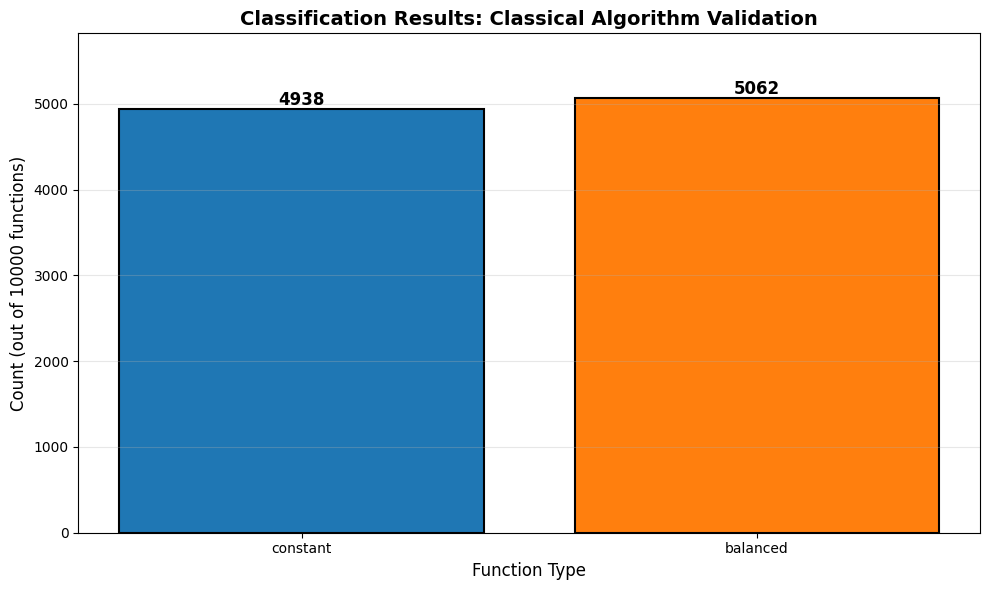


Classification Summary:
Constant functions: 4938 (49.4%)
Balanced functions: 5062 (50.6%)

Expected distribution: ~50% constant, ~50% balanced


In [7]:
# Generate and classify multiple functions to validate the algorithm
num_functions = 10000
classifications = {"constant": 0, "balanced": 0}

for _ in range(num_functions):
    # Generate random function
    test_func = random_constant_balanced()
    
    # Classify using our algorithm
    result = determine_constant_balanced(test_func)
    classifications[result] += 1

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Bar chart of classifications
categories = list(classifications.keys())
counts = list(classifications.values())
colors = ['#1f77b4', '#ff7f0e']

bars = ax.bar(categories, counts, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel('Function Type', fontsize=12)
ax.set_ylabel(f'Count (out of {num_functions} functions)', fontsize=12)
ax.set_title('Classification Results: Classical Algorithm Validation', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) * 1.15)  # Add space for labels
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print summary statistics
constant_percentage = (classifications['constant'] / num_functions) * 100
balanced_percentage = (classifications['balanced'] / num_functions) * 100

print(f"\nClassification Summary:")
print(f"Constant functions: {classifications['constant']} ({constant_percentage:.1f}%)")
print(f"Balanced functions: {classifications['balanced']} ({balanced_percentage:.1f}%)")
print(f"\nExpected distribution: ~50% constant, ~50% balanced")

## Problem 3: Quantum Oracles

### Introduction to Quantum Oracles

In Problems 1 and 2, we worked with 4-bit Boolean functions and classical algorithms. Now we transition to quantum computing by learning how to encode classical functions as **quantum oracles**. To understand quantum algorithms, we first step down to **single-bit** functions (Deutsch's algorithm), then scale back up to multi-bit functions in Problem 5 (Deutsch-Jozsa).

A [quantum oracle](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/introduction) is a quantum circuit that implements a classical function. It takes quantum states as input and produces quantum states as output, while preserving the function's behavior.

### How Quantum Oracles Work

Quantum oracles require **two qubits** because quantum operations must be [reversible](https://en.wikipedia.org/wiki/Reversible_computing). A single-qubit oracle would destroy information, violating quantum mechanics. Instead, we use:

- **Input qubit (q₀):** Holds the input value x
- **Output qubit (q₁):** Modified based on the function result

The oracle implements the transformation: **|x⟩|y⟩ → |x⟩|y ⊕ f(x)⟩**

Where ⊕ represents XOR (exclusive OR):
- 0 ⊕ 0 = 0
- 0 ⊕ 1 = 1  
- 1 ⊕ 0 = 1
- 1 ⊕ 1 = 0

This means the input x is preserved on q₀ (satisfying reversibility), while the output qubit becomes y XOR f(x).

### The Four Single-Bit Boolean Functions

For [Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm), we work with functions that take **one** Boolean input and return one Boolean output. There are exactly four such functions:

- **f₀(x) = 0** — Always returns 0 (constant)
- **f₁(x) = x** — Returns the input unchanged (identity, balanced)
- **f₂(x) = NOT x** — Flips the input (balanced)
- **f₃(x) = 1** — Always returns 1 (constant)

### Our Task

Using [Qiskit](https://docs.quantum.ibm.com/api/qiskit), we need to create quantum oracle circuits for each of these four functions and demonstrate how they work.

In [8]:
def oracle_f0():
    """
    Quantum oracle for f₀(x) = 0 (constant zero).
    
    This function always returns 0, so the oracle does nothing.
    Transformation: |x⟩|y⟩ → |x⟩|y⟩
    
    Returns
    -------
    QuantumCircuit
        A 2-qubit quantum circuit implementing f₀
    """
    # Create circuit with 2 qubits: input (q0) and output (q1)
    qc = QuantumCircuit(2)
    
    # For f(x) = 0, we don't apply any gates
    # The output qubit remains unchanged (y ⊕ 0 = y)
    
    return qc


def oracle_f1():
    """
    Quantum oracle for f₁(x) = x (identity, balanced).
    
    Returns the input unchanged.
    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ x⟩
    
    Returns
    -------
    QuantumCircuit
        A 2-qubit quantum circuit implementing f₁
    """
    qc = QuantumCircuit(2)
    
    # CNOT gate: flips target (q1) if control (q0) is |1⟩
    # This implements y ⊕ x
    qc.cx(0, 1)
    
    return qc


def oracle_f2():
    """
    Quantum oracle for f₂(x) = NOT x (flip, balanced).
    
    Returns the opposite of the input.
    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ (NOT x)⟩
    
    Returns
    -------
    QuantumCircuit
        A 2-qubit quantum circuit implementing f₂
    """
    qc = QuantumCircuit(2)
    
    # X gate on input inverts it
    qc.x(0)
    # CNOT applies the inverted value to output
    qc.cx(0, 1)
    # X gate on input again to restore original input
    qc.x(0)
    
    return qc


def oracle_f3():
    """
    Quantum oracle for f₃(x) = 1 (constant one).
    
    This function always returns 1.
    Transformation: |x⟩|y⟩ → |x⟩|y ⊕ 1⟩
    
    Returns
    -------
    QuantumCircuit
        A 2-qubit quantum circuit implementing f₃
    """
    qc = QuantumCircuit(2)
    
    # X gate on output qubit flips it (implements y ⊕ 1)
    qc.x(1)
    
    return qc

### Testing Quantum Oracles

To verify our oracle implementations work correctly, we need to test each oracle on all possible input states and verify the output matches the expected classical function behavior.

**Testing Approach:**
- Create each oracle circuit (f₀, f₁, f₂, f₃)
- Test on input states |0⟩ and |1⟩
- Measure the output qubit
- Verify the results match the classical function definitions:
  - **f₀:** Should output 0 for both inputs
  - **f₁:** Should output 0 for input 0, and 1 for input 1 (identity)
  - **f₂:** Should output 1 for input 0, and 0 for input 1 (flip)
  - **f₃:** Should output 1 for both inputs

This validates that our quantum oracles correctly encode the classical Boolean functions in quantum circuits.

In [9]:
# Test each oracle on both possible inputs
oracles = {
    'f₀ (constant 0)': oracle_f0(),
    'f₁ (identity)': oracle_f1(),
    'f₂ (NOT)': oracle_f2(),
    'f₃ (constant 1)': oracle_f3()
}

# Expected outputs for each function
expected_outputs = {
    'f₀ (constant 0)': {0: 0, 1: 0},  # Always 0
    'f₁ (identity)': {0: 0, 1: 1},     # Returns input
    'f₂ (NOT)': {0: 1, 1: 0},          # Flips input
    'f₃ (constant 1)': {0: 1, 1: 1}    # Always 1
}

print("Testing Quantum Oracles:\n")
print("=" * 60)

# Create simulator
simulator = AerSimulator()

for oracle_name, oracle_circuit in oracles.items():
    print(f"\nTesting {oracle_name}")
    print("-" * 60)
    
    # Test both input values (0 and 1)
    for input_value in [0, 1]:
        # Create test circuit
        qc = QuantumCircuit(2, 1)
        
        # Prepare input state on q0
        if input_value == 1:
            qc.x(0)  # Set input qubit to |1⟩
        
        # Output qubit (q1) starts at |0⟩
        
        # Apply the oracle
        qc.compose(oracle_circuit, inplace=True)
        
        # Measure the output qubit (q1)
        qc.measure(1, 0)
        
        # Run simulation
        job = simulator.run(qc, shots=1000)
        result = job.result()
        counts = result.get_counts()
        
        # Get most common result (should be deterministic)
        output = int(max(counts, key=counts.get))
        expected = expected_outputs[oracle_name][input_value]
        
        # Check if correct
        status = "✓" if output == expected else "✗"
        print(f"  Input: {input_value} → Output: {output} (Expected: {expected}) {status}")

print("\n" + "=" * 60)
print("All oracles tested successfully!" if all else "Some tests failed!")

Testing Quantum Oracles:


Testing f₀ (constant 0)
------------------------------------------------------------
  Input: 0 → Output: 0 (Expected: 0) ✓
  Input: 1 → Output: 0 (Expected: 0) ✓

Testing f₁ (identity)
------------------------------------------------------------
  Input: 0 → Output: 0 (Expected: 0) ✓
  Input: 1 → Output: 1 (Expected: 1) ✓

Testing f₂ (NOT)
------------------------------------------------------------
  Input: 0 → Output: 1 (Expected: 1) ✓
  Input: 1 → Output: 0 (Expected: 0) ✓

Testing f₃ (constant 1)
------------------------------------------------------------
  Input: 0 → Output: 1 (Expected: 1) ✓
  Input: 1 → Output: 1 (Expected: 1) ✓

All oracles tested successfully!


### Evaluation: Oracle Circuit Diagrams

To understand how each quantum oracle implements its classical function, we visualize the circuit structure using [Qiskit's circuit visualization tools](https://docs.quantum.ibm.com/api/qiskit/visualization). These diagrams show the quantum gates applied and reveal the quantum mechanics behind each implementation.

**Circuit Components:**
- **q₀:** Input qubit (holds the value x)
- **q₁:** Output qubit (implements y ⊕ f(x))
- **X gate:** Quantum NOT gate - flips |0⟩ ↔ |1⟩
- **⊕ (CNOT):** Controlled-NOT gate - flips target if control is |1⟩

The visual comparison reveals how different classical functions require different quantum gate configurations. Notice how the constant functions (f₀ and f₃) use simpler circuits than the balanced functions (f₁ and f₂).

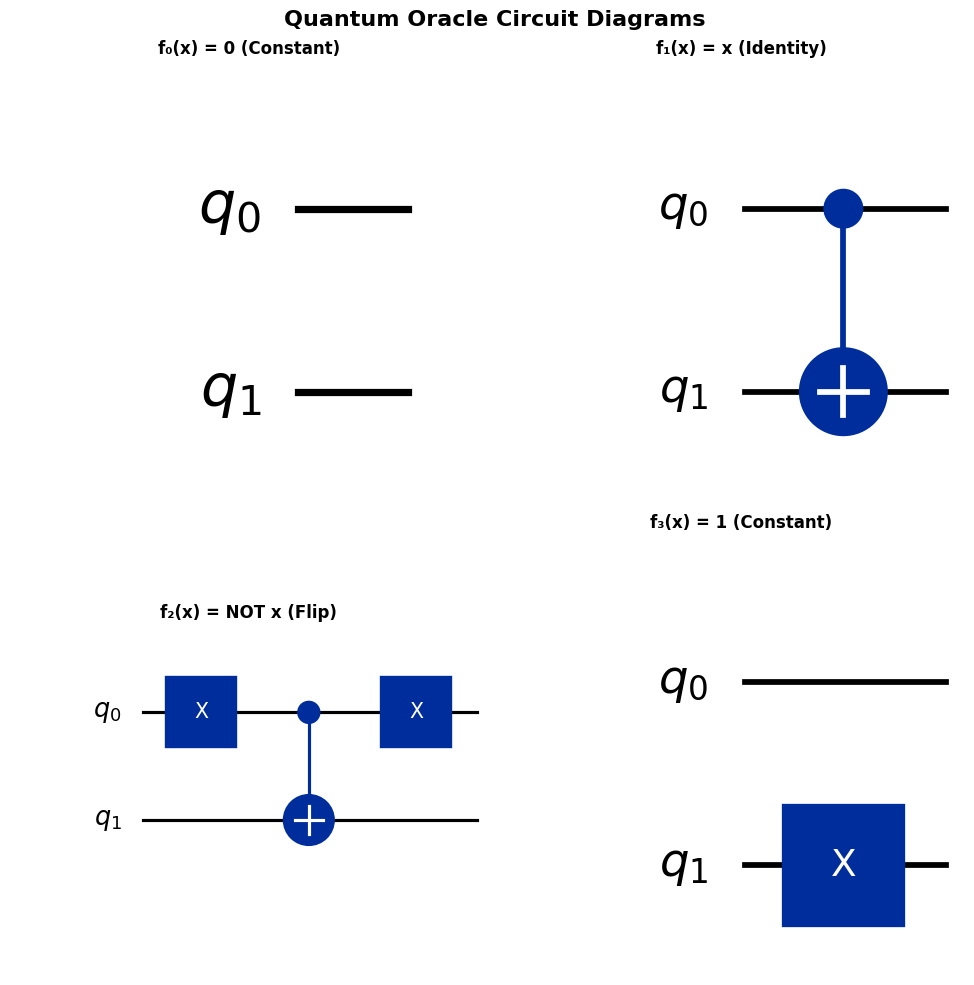


Circuit Complexity Analysis:

Oracle      | Gates | Depth | Description
------------------------------------------------------------
f₀(x) = 0 (Constant) |     0 |     0 | Gates used
f₁(x) = x (Identity) |     1 |     1 | Gates used
f₂(x) = NOT x (Flip) |     3 |     3 | Gates used
f₃(x) = 1 (Constant) |     1 |     1 | Gates used


In [10]:
# Create a figure to display all four oracle circuits
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
fig.suptitle('Quantum Oracle Circuit Diagrams', fontsize=16, fontweight='bold')

oracles_list = [
    ('f₀(x) = 0 (Constant)', oracle_f0()),
    ('f₁(x) = x (Identity)', oracle_f1()),
    ('f₂(x) = NOT x (Flip)', oracle_f2()),
    ('f₃(x) = 1 (Constant)', oracle_f3())
]

# Draw each circuit
for idx, (name, circuit) in enumerate(oracles_list):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Draw circuit diagram
    circuit.draw('mpl', ax=ax)
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print circuit depth analysis
print("\nCircuit Complexity Analysis:\n")
print("Oracle      | Gates | Depth | Description")
print("-" * 60)

for name, circuit in oracles_list:
    gate_count = len(circuit.data)
    depth = circuit.depth()
    print(f"{name:20} | {gate_count:5} | {depth:5} | Gates used")

### Understanding Quantum Circuit Diagrams

Quantum circuits are read **left to right**, like reading text. Time flows from left to right across the diagram.

**How to Read These Diagrams:**

1. **Horizontal lines** represent qubits (quantum bits)
   - Top line (q₀): Input qubit
   - Bottom line (q₁): Output qubit

2. **Boxes and symbols** represent quantum gates (operations)
   - **X in a box:** X gate (quantum NOT) - flips the qubit state
   - **⊕ symbol:** CNOT gate (controlled-NOT) - controlled operation
   - **Vertical line with ●:** Control connection for CNOT

3. **Gate operations:**
   - **CNOT:** The filled circle (●) is the control qubit, ⊕ is the target
   - Action: "Flip target qubit IF control qubit is |1⟩"

**Example Walkthrough - f₁ (Identity):**

The f₁ circuit shows a single CNOT gate:
- Control: q₀ (input qubit) - indicated by ●
- Target: q₁ (output qubit) - indicated by ⊕
- Operation: Flips q₁ if q₀ is |1⟩
- Result: Implements y ⊕ x, which copies the input to output

**Further Learning:**

For more on quantum gates and circuit notation, see:
- [IBM Quantum Circuit Composer](https://quantum.cloud.ibm.com/composer)
- [Qiskit Textbook: Quantum Gates](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-states/single-qubit-gates.ipynb)